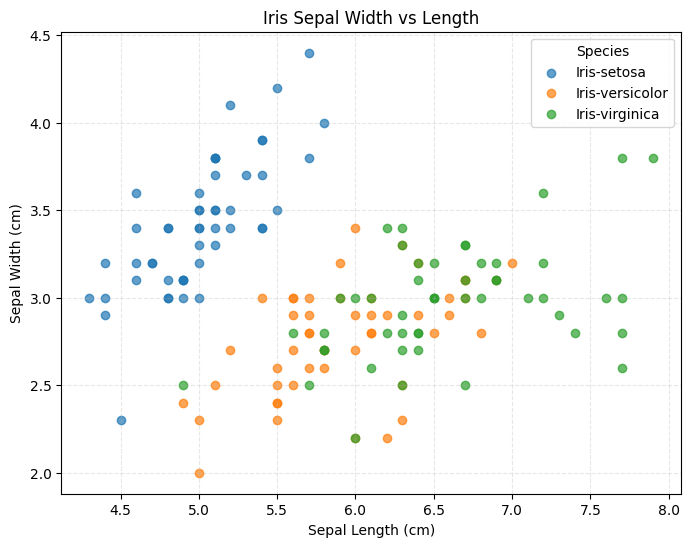

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/irisdata/IRIS.csv")

plt.figure(figsize=(8, 6))
for species, group in df.groupby("species"):
    plt.scatter(group["sepal_length"], group["sepal_width"], label=species, alpha=0.7)

plt.xlabel("Sepal Length (cm)")
plt.ylabel("Sepal Width (cm)")
plt.title("Iris Sepal Width vs Length")
plt.legend(title="Species")
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

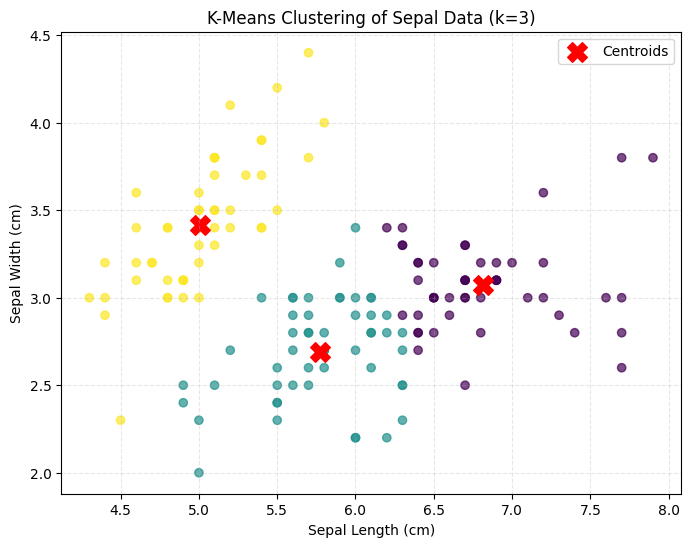

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

df = pd.read_csv("data/irisdata/IRIS.csv")

# Pretend we only have the sepal measurements (no species labels)
X = df[["sepal_length", "sepal_width"]]

k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)
centers = kmeans.cluster_centers_

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X["sepal_length"], X["sepal_width"], c=labels, cmap="viridis", alpha=0.7)
plt.scatter(centers[:, 0], centers[:, 1], c="red", marker="X", s=200, label="Centroids")

plt.xlabel("Sepal Length (cm)")
plt.ylabel("Sepal Width (cm)")
plt.title(f"K-Means Clustering of Sepal Data (k={k})")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

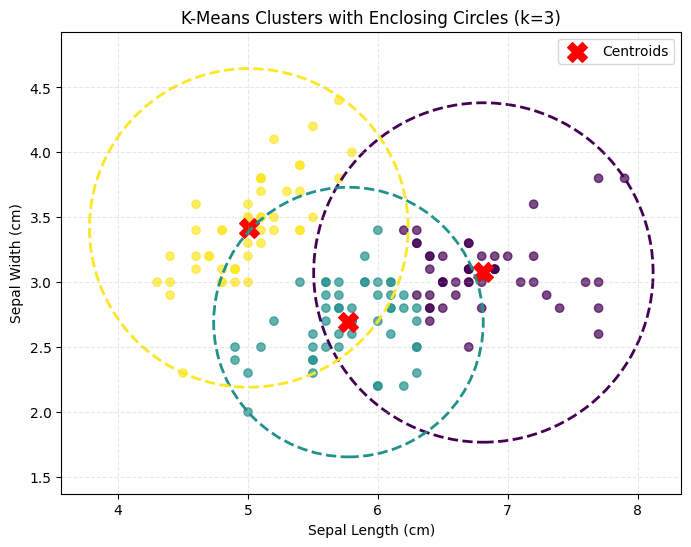

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from sklearn.cluster import KMeans

df = pd.read_csv("data/irisdata/IRIS.csv")

# Pretend we only have the sepal measurements (no species labels)
X = df[["sepal_length", "sepal_width"]].values

k = 6
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)
centers = kmeans.cluster_centers_

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(X[:, 0], X[:, 1], c=labels, cmap="viridis", alpha=0.7)
ax.scatter(centers[:, 0], centers[:, 1], c="red", marker="X", s=200, label="Centroids")

cmap = plt.get_cmap("viridis")
for i in range(k):
    points = X[labels == i]
    distances = np.linalg.norm(points - centers[i], axis=1)
    radius = distances.max()  # circle encloses all points in the cluster
    color = cmap(i / (k - 1)) if k > 1 else cmap(0.0)
    circle = Circle(centers[i], radius, color=color, fill=False, linewidth=2, linestyle="--")
    ax.add_patch(circle)

ax.set_xlabel("Sepal Length (cm)")
ax.set_ylabel("Sepal Width (cm)")
ax.set_title(f"K-Means Clusters with Enclosing Circles (k={k})")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.3)
ax.set_aspect("equal", adjustable="datalim")
plt.show()